# **Fetal health**

## 1. Problem definition

The goal of this model is to develop an accurate and reliable classification system that will categorize fetuses into three classes (healthy, suspect, pathogenic). There is a need for early detection of potential health problems in pregnant women in order to take preventive measures and provide support in the early stages of pregnancy. The model is intended to support clinicians in making informed decisions. This means that clinicians need tools to help them analyze fetal health data and make decisions that will improve pregnancy outcomes. The main purpose of the model is to reduce risks for the mother and newborn. This is achieved by timely recognition of potential complications and providing appropriate medical attention.

Dataset used for the purpose of the project is on the [link](https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification/data).

The measures of success that will be used in the project are the confusion matrix, sensitivity, accuracy, precision, specificity and F1 score

## 2. Dataset description

* Importing modules




In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split


* Loading the database

In [ ]:
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/11/Fetal health/fetal_health.csv"

data = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Basic analysis of the data

In [ ]:
data.shape

(2126, 22)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [ ]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [ ]:
data.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

In [ ]:
data.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.000,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,...,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,3.0
6,134.0,0.001,0.0,0.013,0.008,0.0,0.003,29.0,6.3,0.0,...,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,3.0
7,122.0,0.000,0.0,0.000,0.000,0.0,0.000,83.0,0.5,6.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
8,122.0,0.000,0.0,0.002,0.000,0.0,0.000,84.0,0.5,5.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
9,122.0,0.000,0.0,0.003,0.000,0.0,0.000,86.0,0.3,6.0,...,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0,3.0


### 2.1 Exploratory data analysis

* Distribution of the target feature *fetal_health*

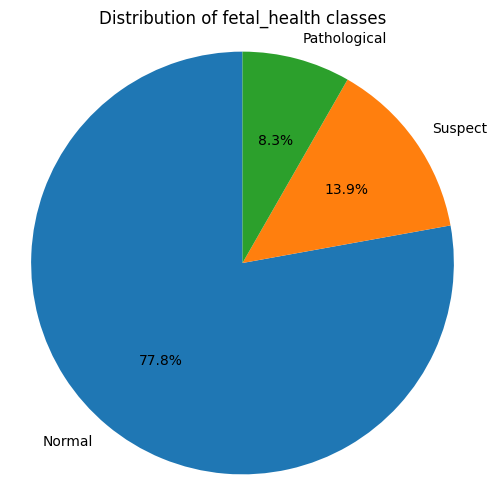

In [ ]:
target_values = data['fetal_health'].value_counts().sort_index()
label_map = {
    1: 'Normal',
    2: 'Suspect',
    3: 'Pathological'
}
labels = [label_map[val] for val in target_values.index]
sizes = target_values.values

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of fetal_health classes')
plt.axis('equal')
plt.show()

The target variable exhibits a pronounced imbalance across classes, with one class being substantially more frequent than the others. Consequently, it is essential to design or select learning algorithms that explicitly account for this characteristic of the dataset to avoid biased predictions and degraded performance on minority classes. Moreover, these minority classes correspond to the most clinically critical cases, making their accurate detection particularly important despite their low prevalence.

* Distribution of all numerical features

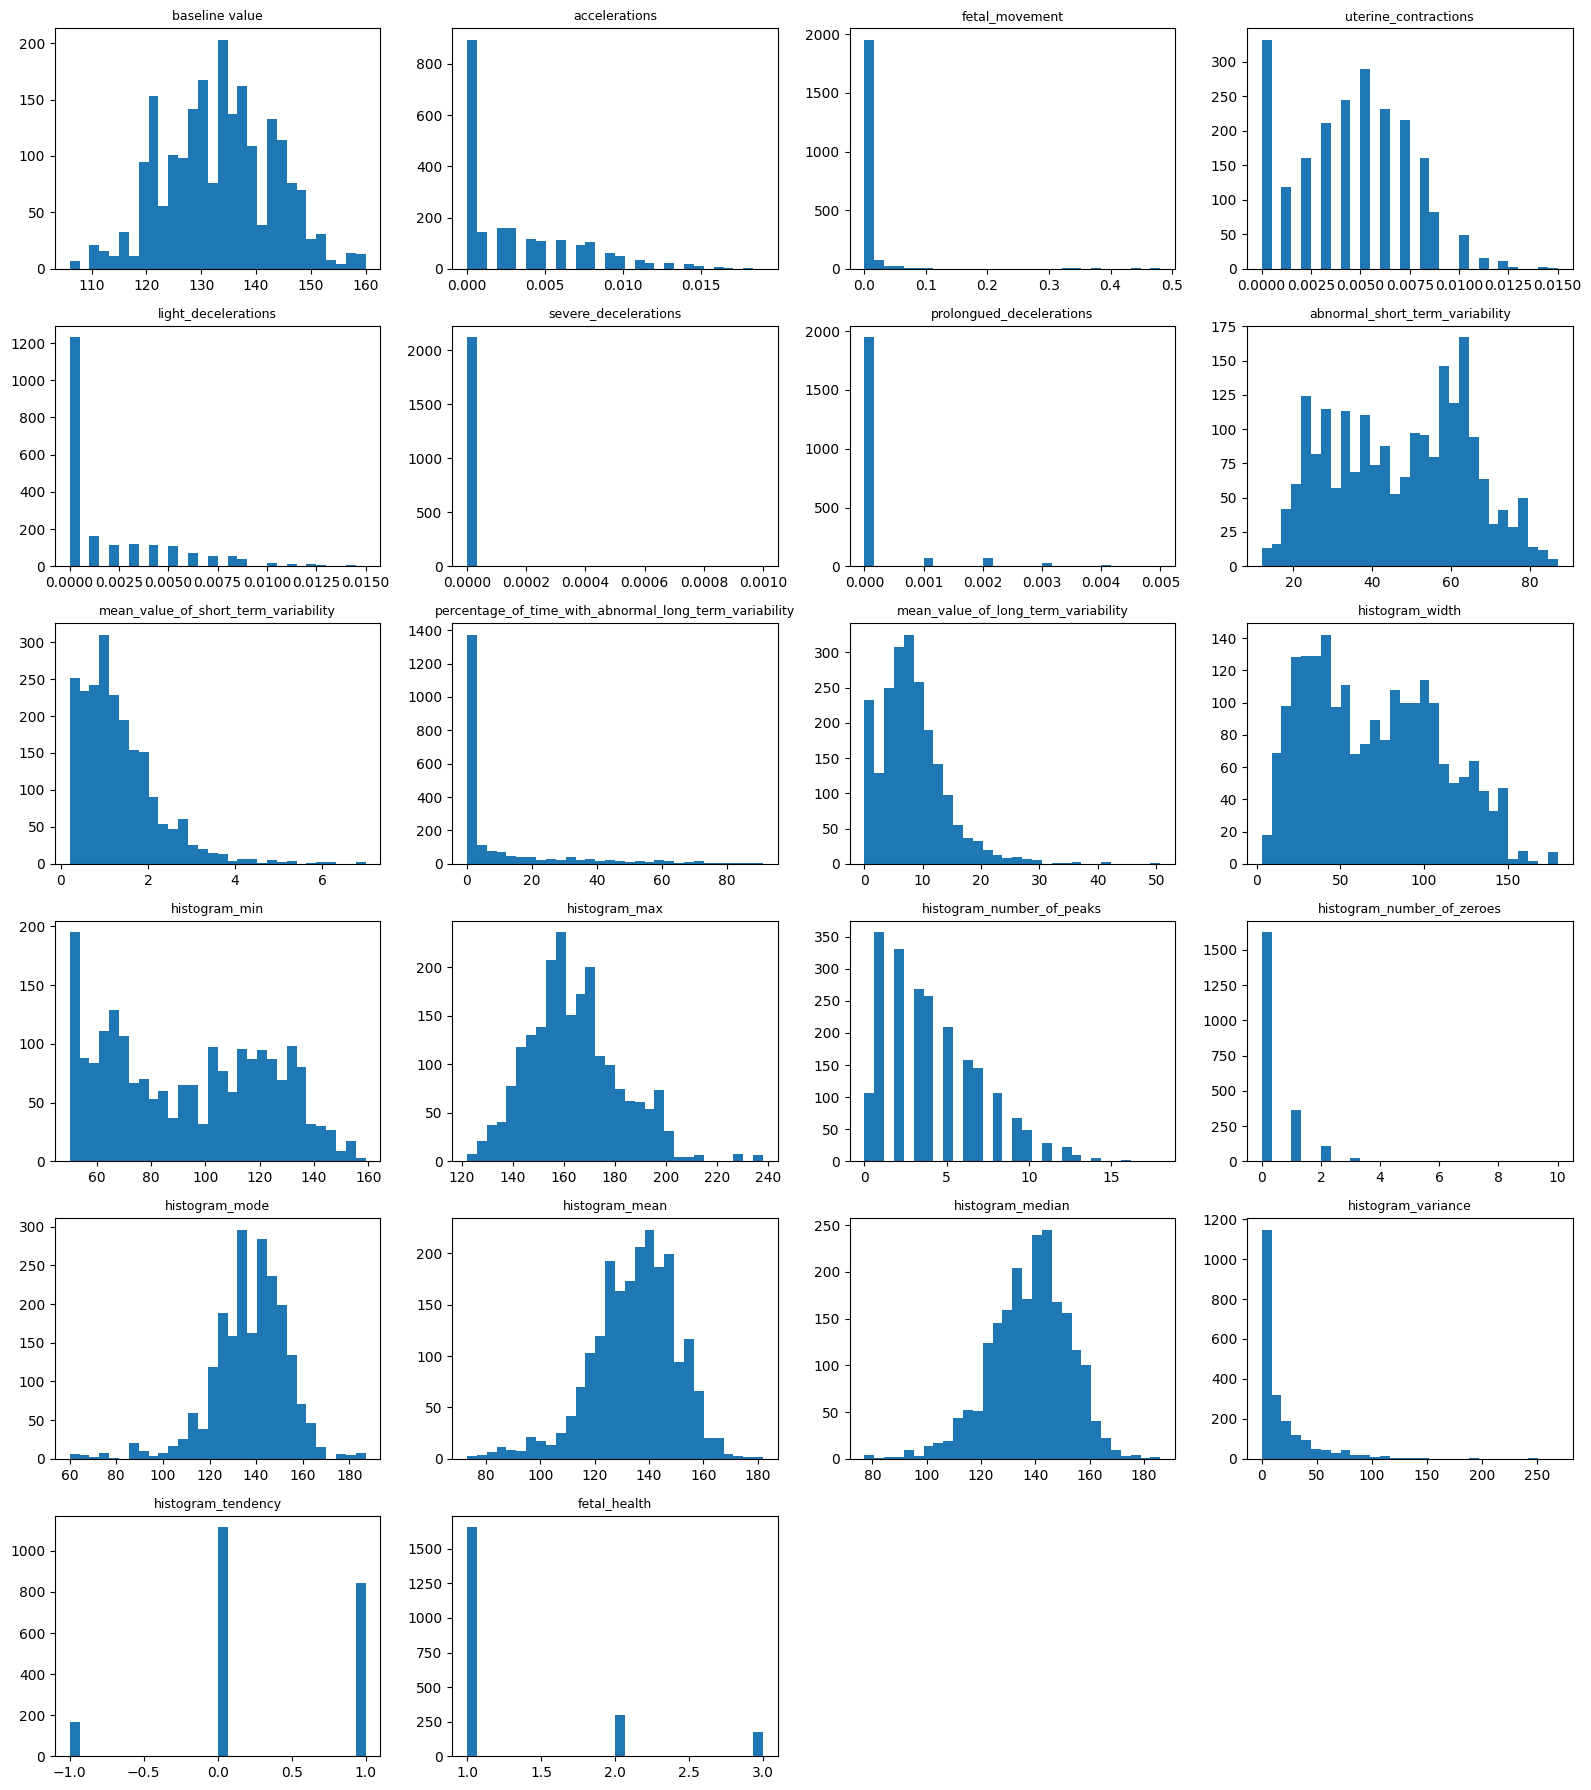

In [ ]:
numeric_features = data.select_dtypes(include=['int64', 'float64'])
n_features = numeric_features.shape[1]
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, col in enumerate(numeric_features.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(numeric_features[col].dropna(), bins=30)
    plt.title(col, fontsize=9)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

* Correlation matrix between key features

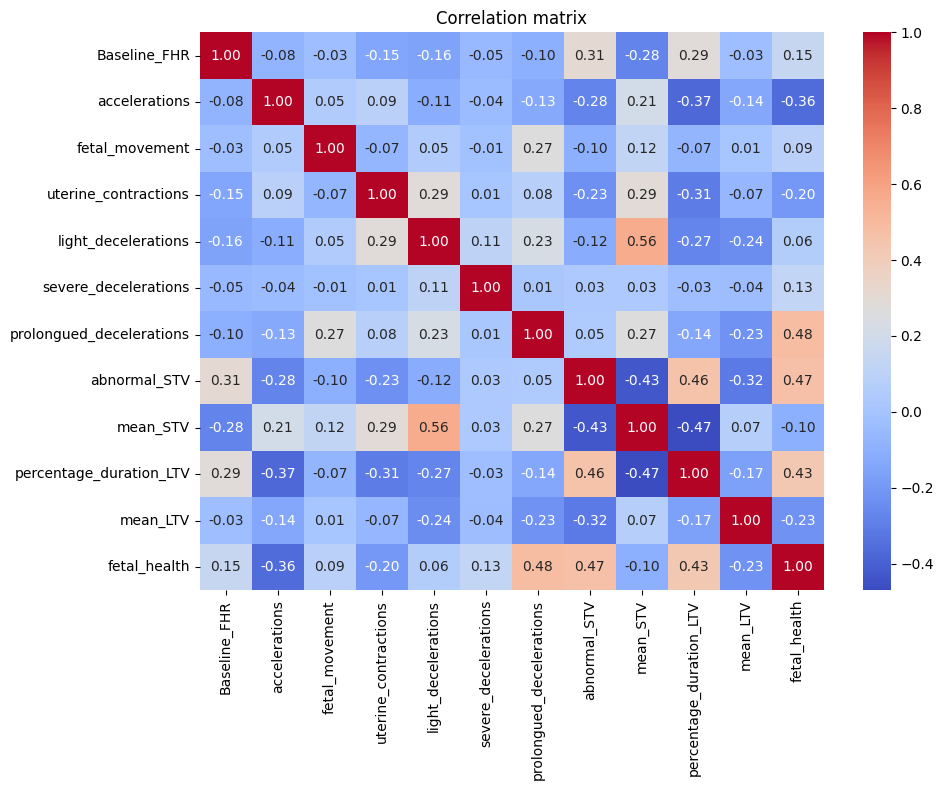

In [ ]:
# we are taking only features that are fundamental
basic_cols = [
    'baseline value',
    'accelerations',
    'fetal_movement',
    'uterine_contractions',
    'light_decelerations',
    'severe_decelerations',
    'prolongued_decelerations',
    'abnormal_short_term_variability',
    'mean_value_of_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
    'mean_value_of_long_term_variability',
    'fetal_health'
]

basic_features = data[basic_cols].copy()

# renaming for better visual
basic_features.rename(columns={
    'baseline value': 'Baseline_FHR',
    'abnormal_short_term_variability': 'abnormal_STV',
    'mean_value_of_short_term_variability': 'mean_STV',
    'percentage_of_time_with_abnormal_long_term_variability': 'percentage_duration_LTV',
    'mean_value_of_long_term_variability': 'mean_LTV'
}, inplace=True)

correlation_matrix = basic_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

From the correlation matrix, we can notice strong positive correlation of the target feature with *prolongued_decelerations*, *abnormal_short_term_variability* and *percentage_during_long_term_variability*. On the other hand, we are observing a strong negative correlation of the *fetal_health* feature with *accelerations* and slight negative correlation with *uterine_contractions* and *mean_long_term_variability*

### 2.2 Data pre-processing

* Handling missing values

In [ ]:
print(data.isnull().sum())

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

There is no missing data

* Standardization of the data and splitting to train and test

In [ ]:
X = data.drop(columns=['fetal_health'])
y = data['fetal_health'].astype(int) - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = X.columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'
)

## **3. Baseline models**

For the baseline models, we are creating XGBoost, Random forest and Support vector machine



*   Util functions



In [ ]:
def evaluate_model(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)  # sensitivity
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    specificities = []
    n_classes = cm.shape[0]
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)
        spec_i = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specificities.append(spec_i)
    specificity = np.mean(specificities)

    print("\tAccuracy:", acc)
    print("\tPrecision:", precision)
    print("\tSensitivity / Recall:", recall)
    print("\tF1-score:", f1)
    print("\tSpecificity:", specificity)

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap='Blues')

    class_names = ["Normal", "Suspect", "Pathological"]

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title("Confusion matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Random forest

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Training of Random Forest + GridSearchCV...")
rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
print("Best RF F1 score:", rf_grid.best_score_)

Training of Random Forest + GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF parameters: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF F1 score: 0.8972573134299436


Random forest results:
	Accuracy: 0.9342723004694836
	Precision: 0.9143374876804272
	Sensitivity / Recall: 0.8534141408248005
	F1-score: 0.8782494721439772
	Specificity: 0.9219791433601522


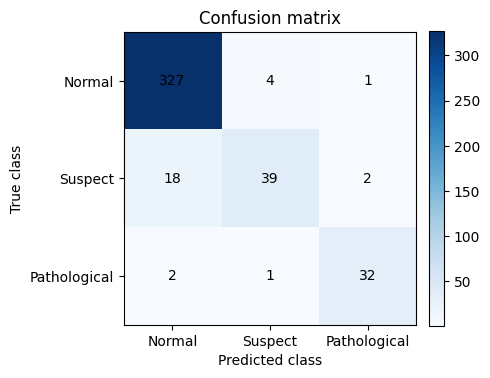

In [ ]:
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("Random forest results:")
evaluate_model(y_test, y_pred_rf, labels=[0, 1, 2])

XGBoost

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    ))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("\nTraining of XGBoost + GridSearchCV")
xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:", xgb_grid.best_params_)
print("Best XGBoost F1 score:", xgb_grid.best_score_)


Training of XGBoost + GridSearchCV
Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:23:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best XGBoost F1 score: 0.9248612735481805


XGBoost results: 
	Accuracy: 0.9413145539906104
	Precision: 0.9150177029876277
	Sensitivity / Recall: 0.8750089948170405
	F1-score: 0.8926470203423714
	Specificity: 0.9352552753098305


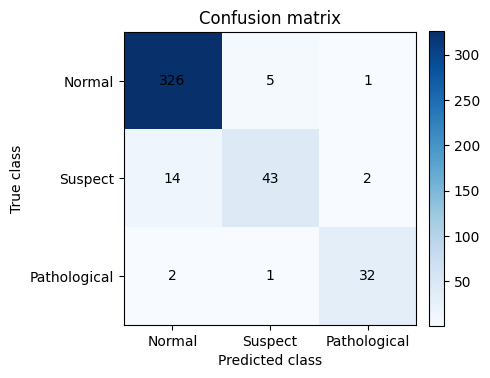

In [ ]:
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

print("XGBoost results: ")
evaluate_model(y_test, y_pred_xgb, labels=[0, 1, 2])

Support vector machine

In [ ]:
svm_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', SVC())
])

svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.001],
    'model__kernel': ['rbf']
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Training of SVM + GridSearchCV...")
svm_grid.fit(X_train, y_train)

print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM F1 score", svm_grid.best_score_)

Training of SVM + GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best SVM parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVM F1 score 0.8594509923708241


Support vector machine results:
	Accuracy: 0.9107981220657277
	Precision: 0.8500290258910949
	Sensitivity / Recall: 0.7922552194249152
	F1-score: 0.8183891665365194
	Specificity: 0.9155343253030669


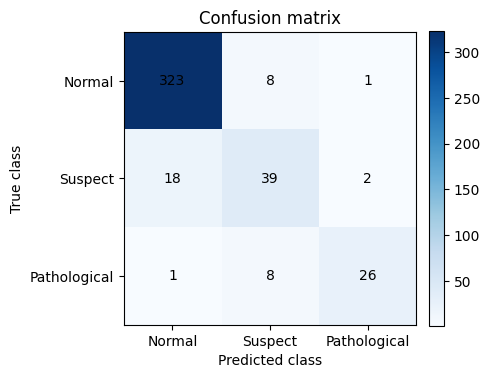

In [ ]:
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test)

print("Support vector machine results:")
evaluate_model(y_test, y_pred_svm, labels=[0, 1, 2])